In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import arviz as az

# --- Resolve repo root ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

assert (REPO_ROOT / "src").exists(), f"Not in resilient-housing-bayes repo: {REPO_ROOT}"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)

Repo root: C:\Users\C.Price\Habnetic\resilient-housing-bayes


In [2]:
from src.rtm.io_hazard import load_rtm_pluvial_v1_buildings

# Exposure
E_PATH = REPO_ROOT / "outputs" / "rtm" / "water_exposure_Ehat_v0.parquet"
assert E_PATH.exists(), f"Missing exposure: {E_PATH}"
E_df = pd.read_parquet(E_PATH)[["bldg_id", "E_hat"]]

# Hazard (canonical loader)
H_df = load_rtm_pluvial_v1_buildings()[["bldg_id", "H_pluvial_v1_mm"]]

df_city = E_df.merge(H_df, on="bldg_id", validate="one_to_one")
print("City rows:", len(df_city))
df_city.head()

City rows: 221324


,bldg_id,E_hat,H_pluvial_v1_mm
0,305012,0.536838,25.422161
1,313960,0.677579,25.418823
2,313263,0.251841,25.423113
3,310491,0.189019,25.424500
4,313127,-0.292821,25.423491


In [3]:
E = df_city["E_hat"].to_numpy(dtype=np.float64)
H = df_city["H_pluvial_v1_mm"].to_numpy(dtype=np.float64)

E_mu, E_sd = float(E.mean()), float(E.std(ddof=1))
H_mu, H_sd = float(H.mean()), float(H.std(ddof=1))

# Avoid divide-by-zero paranoia
E_sd = E_sd if E_sd > 0 else 1.0
H_sd = H_sd if H_sd > 0 else 1.0

df_city["E_std_city"] = ((E - E_mu) / E_sd).astype(np.float32)
df_city["H_std_city"] = ((H - H_mu) / H_sd).astype(np.float32)

print("E_mu, E_sd:", E_mu, E_sd)
print("H_mu, H_sd:", H_mu, H_sd)
df_city[["E_std_city", "H_std_city"]].describe()

E_mu, E_sd: -8.218672188944066e-17 0.8402606374466663
H_mu, H_sd: 25.668643700884974 0.19523953639485464


,E_std_city,H_std_city
count,2.213240e+05,2.213240e+05
mean,-8.824732e-09,-8.824732e-09
std,1.000000e+00,1.000000e+00
min,-3.441534e+00,-1.334169e+00
25%,-4.709318e-01,-7.810058e-01
50%,3.721495e-01,-1.276831e-01
75%,6.694652e-01,4.082617e-01
max,2.699381e+00,4.283359e+00


In [4]:
INF_DIR = REPO_ROOT / "outputs" / "rtm" / "inference"
assert INF_DIR.exists(), f"Missing inference dir: {INF_DIR}"

# Pick the idata files you want to score over the full city.
# Examples (adjust names to your actual files):
IDATA_FILES = {
    "v1b_p05": INF_DIR / "rtm_damage_v1b_logistic_idata.nc",
    "v1b_p02": INF_DIR / "rtm_damage_v1b_p02_logistic_idata.nc",
    "v1b_p10": INF_DIR / "rtm_damage_v1b_p10_logistic_idata.nc",
    # "v1c_bE10_bH06": INF_DIR / "rtm_damage_v1c_bE10_bH06_logistic_idata.nc",
    # "v1c_bE02_bH06": INF_DIR / "rtm_damage_v1c_bE02_bH06_logistic_idata.nc",
    # "v1c_bE10_bH02": INF_DIR / "rtm_damage_v1c_bE10_bH02_logistic_idata.nc",
}

for k, p in IDATA_FILES.items():
    print(k, "->", p, "| exists:", p.exists())

v1b_p05 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_logistic_idata.nc | exists: True
v1b_p02 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_p02_logistic_idata.nc | exists: True
v1b_p10 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_p10_logistic_idata.nc | exists: True


In [5]:
def load_posterior_draws(idata_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    idata = az.from_netcdf(idata_path)
    post = idata.posterior

    for v in ["alpha", "beta_E", "beta_H"]:
        assert v in post.data_vars, f"Missing {v} in posterior of {idata_path.name}"

    alpha = post["alpha"].values.reshape(-1).astype(np.float64)   # (S,)
    beta_E = post["beta_E"].values.reshape(-1).astype(np.float64)
    beta_H = post["beta_H"].values.reshape(-1).astype(np.float64)

    return alpha, beta_E, beta_H

In [6]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def score_city_pmean_psd(
    alpha: np.ndarray,
    beta_E: np.ndarray,
    beta_H: np.ndarray,
    E_std: np.ndarray,
    H_std: np.ndarray,
    building_chunk: int = 50_000,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes posterior mean and sd of p_i over all buildings, chunked over buildings.
    Memory footprint: O(S * chunk).
    """
    S = alpha.shape[0]
    N = E_std.shape[0]

    p_mean = np.empty(N, dtype=np.float32)
    p_sd = np.empty(N, dtype=np.float32)

    for i0 in range(0, N, building_chunk):
        i1 = min(N, i0 + building_chunk)

        # (S, chunk)
        logits = (
            alpha[:, None]
            + beta_E[:, None] * E_std[None, i0:i1]
            + beta_H[:, None] * H_std[None, i0:i1]
        )
        p = sigmoid(logits)

        p_mean[i0:i1] = p.mean(axis=0).astype(np.float32)
        p_sd[i0:i1] = p.std(axis=0).astype(np.float32)

        print(f"Scored buildings {i0:,}..{i1:,} / {N:,}")

    return p_mean, p_sd

In [7]:
def score_city_topk_prob(
    alpha: np.ndarray,
    beta_E: np.ndarray,
    beta_H: np.ndarray,
    E_std: np.ndarray,
    H_std: np.ndarray,
    k: int,
    draw_chunk: int = 100,
) -> np.ndarray:
    """
    For each posterior draw, compute top-k buildings by p_i.
    Accumulate membership counts -> topk_prob.

    Complexity: O(S * N). Works if S and k are modest and numpy is fast on your machine.
    """
    S = alpha.shape[0]
    N = E_std.shape[0]
    counts = np.zeros(N, dtype=np.int32)

    for s0 in range(0, S, draw_chunk):
        s1 = min(S, s0 + draw_chunk)

        a = alpha[s0:s1]
        bE = beta_E[s0:s1]
        bH = beta_H[s0:s1]

        logits = (
            a[:, None]
            + bE[:, None] * E_std[None, :]
            + bH[:, None] * H_std[None, :]
        )
        p = sigmoid(logits)  # (chunk, N)

        idx = np.argpartition(p, -k, axis=1)[:, -k:]  # (chunk, k)
        for row in idx:
            counts[row] += 1

        print(f"Processed draws {s0}..{s1} / {S}")

    return (counts / float(S)).astype(np.float32)

In [8]:
OUT_BASE = REPO_ROOT / "outputs" / "rtm" / "city_scoring"
OUT_BASE.mkdir(parents=True, exist_ok=True)
print("OUT_BASE:", OUT_BASE)

E_std_city = df_city["E_std_city"].to_numpy(dtype=np.float64)
H_std_city = df_city["H_std_city"].to_numpy(dtype=np.float64)
N_city = len(df_city)

# Pick ks you actually care about
K_LIST = [1000, 2500, 5000]   # adjust, but keep small at first

results = []

for scenario, idata_path in IDATA_FILES.items():
    assert idata_path.exists(), f"Missing idata: {idata_path}"

    print("\n=== Scenario:", scenario, "===")
    alpha, beta_E, beta_H = load_posterior_draws(idata_path)
    S = alpha.shape[0]
    print("Posterior draws S:", S)

    p_mean_city, p_sd_city = score_city_pmean_psd(
        alpha, beta_E, beta_H, E_std_city, H_std_city, building_chunk=50_000
    )

    out_dir = OUT_BASE / scenario
    out_dir.mkdir(parents=True, exist_ok=True)

    # Base scoring table (always)
    scored = pd.DataFrame({
        "bldg_id": df_city["bldg_id"].to_numpy(),
        "p_mean_city": p_mean_city,
        "p_sd_city": p_sd_city,
    })

    # Optional topk probs
    for k in K_LIST:
        assert k <= N_city, f"k={k} > N_city={N_city}"
        print(f"Computing topk_prob_city for k={k} ...")
        scored[f"topk_prob_city_{k}"] = score_city_topk_prob(
            alpha, beta_E, beta_H, E_std_city, H_std_city, k=k, draw_chunk=100
        )

        # sanity check identity: mean(topk_prob) == k/N (approximately)
        print(f"Sanity mean(topk_prob_city_{k}) =", float(scored[f"topk_prob_city_{k}"].mean()),
              "| expected =", k / N_city)

    # Save parquet for QGIS join / downstream
    out_path = out_dir / "rtm_city_scoring.parquet"
    scored.to_parquet(out_path, index=False)
    print("Saved:", out_path, "| rows:", len(scored))

    # Save a tiny metadata json-ish csv row
    results.append({
        "scenario": scenario,
        "idata_file": idata_path.name,
        "N_city": N_city,
        "S_draws": S,
        "E_mu": E_mu, "E_sd": E_sd,
        "H_mu": H_mu, "H_sd": H_sd,
        "K_LIST": ",".join(map(str, K_LIST)),
        "out_path": str(out_path),
    })

summary = pd.DataFrame(results)
summary_path = OUT_BASE / "city_scoring_summary.csv"
summary.to_csv(summary_path, index=False)
print("\nSaved:", summary_path)
summary

OUT_BASE: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\city_scoring

=== Scenario: v1b_p05 ===
Posterior draws S: 1000
Scored buildings 0..50,000 / 221,324
Scored buildings 50,000..100,000 / 221,324
Scored buildings 100,000..150,000 / 221,324
Scored buildings 150,000..200,000 / 221,324
Scored buildings 200,000..221,324 / 221,324
Computing topk_prob_city for k=1000 ...
Processed draws 0..100 / 1000
Processed draws 100..200 / 1000
Processed draws 200..300 / 1000
Processed draws 300..400 / 1000
Processed draws 400..500 / 1000
Processed draws 500..600 / 1000
Processed draws 600..700 / 1000
Processed draws 700..800 / 1000
Processed draws 800..900 / 1000
Processed draws 900..1000 / 1000
Sanity mean(topk_prob_city_1000) = 0.004518263041973114 | expected = 0.004518262818311616
Computing topk_prob_city for k=2500 ...
Processed draws 0..100 / 1000
Processed draws 100..200 / 1000
Processed draws 200..300 / 1000
Processed draws 300..400 / 1000
Processed draws 400..500 / 1000
Proce

,scenario,idata_file,N_city,S_draws,E_mu,E_sd,H_mu,H_sd,K_LIST,out_path
0,v1b_p05,rtm_damage_v1b_logistic_idata.nc,221324,1000,-8.218672e-17,0.840261,25.668644,0.19524,"1000,2500,5000",C:\Users\C.Price\Habnetic\resilient-housing-ba...
1,v1b_p02,rtm_damage_v1b_p02_logistic_idata.nc,221324,1000,-8.218672e-17,0.840261,25.668644,0.19524,"1000,2500,5000",C:\Users\C.Price\Habnetic\resilient-housing-ba...
2,v1b_p10,rtm_damage_v1b_p10_logistic_idata.nc,221324,1000,-8.218672e-17,0.840261,25.668644,0.19524,"1000,2500,5000",C:\Users\C.Price\Habnetic\resilient-housing-ba...


In [9]:
scenario = list(IDATA_FILES.keys())[0]
p = OUT_BASE / scenario / "rtm_city_scoring.parquet"
df_sc = pd.read_parquet(p)

df_sc.sort_values("p_mean_city", ascending=False).head(20)

,bldg_id,p_mean_city,p_sd_city,topk_prob_city_1000,topk_prob_city_2500,topk_prob_city_5000
125202,51795,0.767900,0.035569,1.0,1.0,1.0
125230,51733,0.751574,0.036199,1.0,1.0,1.0
125161,51901,0.736052,0.036714,1.0,1.0,1.0
124230,52659,0.732093,0.036902,1.0,1.0,1.0
125045,51951,0.729356,0.036903,1.0,1.0,1.0
125033,51975,0.727630,0.036950,1.0,1.0,1.0
124983,52041,0.725598,0.037007,1.0,1.0,1.0
125012,52007,0.720039,0.037136,1.0,1.0,1.0
105592,53376,0.713425,0.037368,1.0,1.0,1.0
125278,51667,0.712437,0.037288,1.0,1.0,1.0


In [17]:
df_sc["p_mean_city"].describe(percentiles=[0.5,0.9,0.99])

count    221324.000000
mean          0.077432
std           0.079035
min           0.000646
50%           0.054756
90%           0.166297
99%           0.420844
max           0.767900
Name: p_mean_city, dtype: float64

In [10]:
for k in [1000, 2500, 5000]:
    col = f"topk_prob_city_{k}"
    print(k, 
          "mean =", df_sc[col].mean(),
          "expected =", k/221324,
          "borderline share =",
          ((df_sc[col] > 0.2) & (df_sc[col] < 0.8)).mean())

1000 mean = 0.004518263 expected = 0.004518262818311616 borderline share = 0.0005241184869241474
2500 mean = 0.011295657 expected = 0.01129565704577904 borderline share = 0.0011837848583976433
5000 mean = 0.022591313 expected = 0.02259131409155808 borderline share = 0.002891688203719434


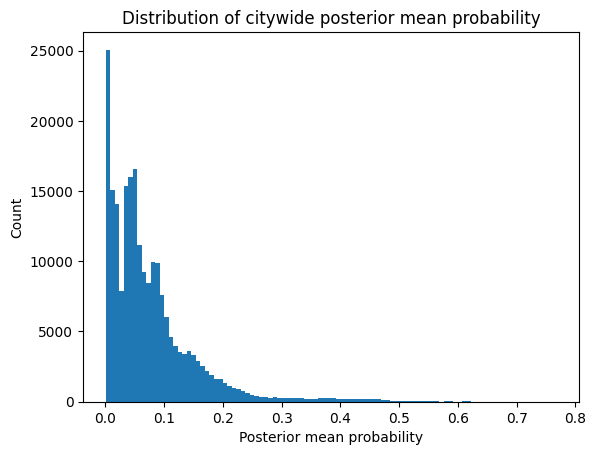

In [11]:
# Histogram of p_mean_city

import matplotlib.pyplot as plt

plt.hist(df_sc["p_mean_city"], bins=100)
plt.xlabel("Posterior mean probability")
plt.ylabel("Count")
plt.title("Distribution of citywide posterior mean probability")
plt.show()

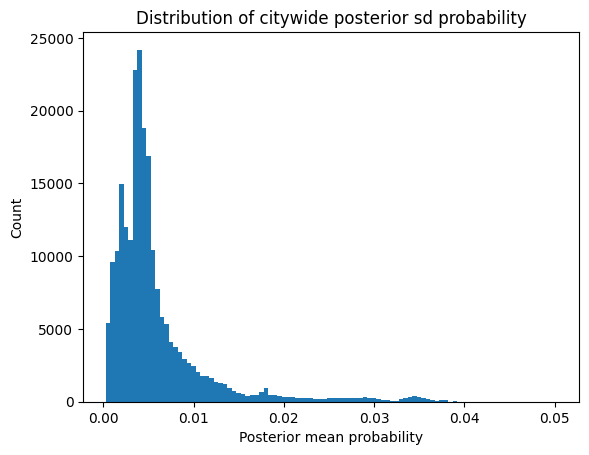

In [12]:
#Histogram p_sd_city

import matplotlib.pyplot as plt

plt.hist(df_sc["p_sd_city"], bins=100)
plt.xlabel("Posterior mean probability")
plt.ylabel("Count")
plt.title("Distribution of citywide posterior sd probability")
plt.show()

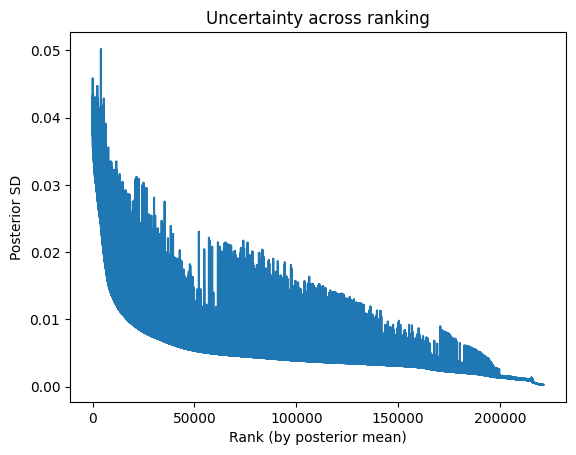

In [13]:
# Rank vs posterior SD

df_sc_sorted = df_sc.sort_values("p_mean_city", ascending=False).reset_index(drop=True)
df_sc_sorted["rank"] = df_sc_sorted.index + 1

plt.plot(df_sc_sorted["rank"], df_sc_sorted["p_sd_city"])
plt.xlabel("Rank (by posterior mean)")
plt.ylabel("Posterior SD")
plt.title("Uncertainty across ranking")
plt.show()

Summary:
Mean: 0.004518263
Min: 0.0
Max: 1.0
Borderline share (0.2 < p < 0.8): 0.0005241184869241474


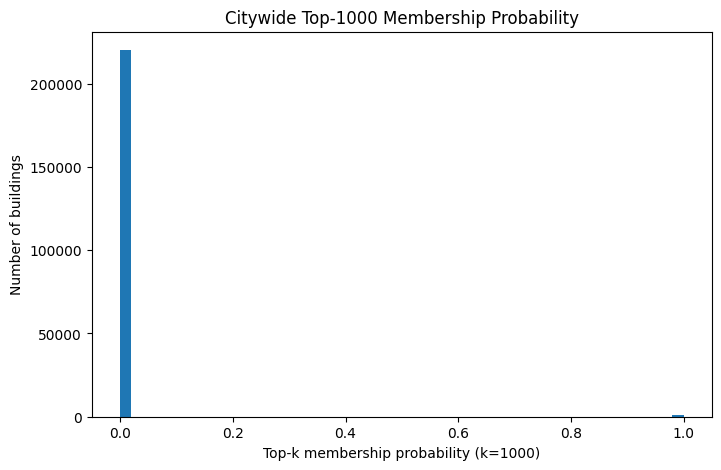

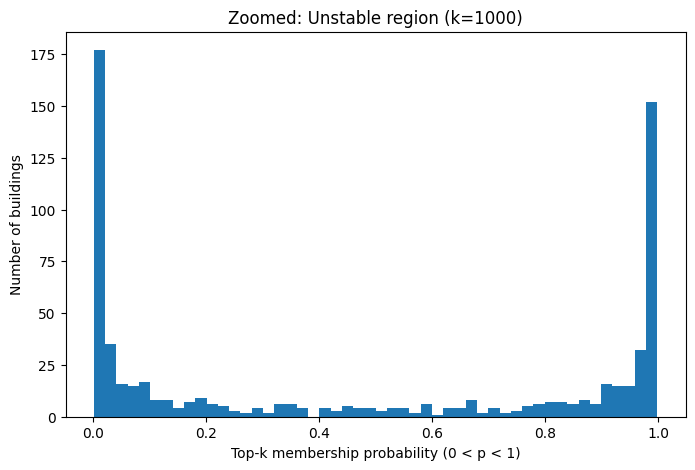

In [14]:
# Histogram of topk_prob_city_1000
import matplotlib.pyplot as plt
import numpy as np

col = "topk_prob_city_1000"

vals = df_sc[col].values

print("Summary:")
print("Mean:", vals.mean())
print("Min:", vals.min())
print("Max:", vals.max())
print("Borderline share (0.2 < p < 0.8):",
      np.mean((vals > 0.2) & (vals < 0.8)))

plt.figure(figsize=(8,5))
plt.hist(vals, bins=50)
plt.xlabel("Top-k membership probability (k=1000)")
plt.ylabel("Number of buildings")
plt.title("Citywide Top-1000 Membership Probability")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(vals[(vals > 0) & (vals < 1)], bins=50)
plt.xlabel("Top-k membership probability (0 < p < 1)")
plt.ylabel("Number of buildings")
plt.title("Zoomed: Unstable region (k=1000)")
plt.show()

Summary:
Mean: 0.004518263
Min: 0.0
Max: 1.0
Borderline share (0.2 < p < 0.8): 0.0005241184869241474


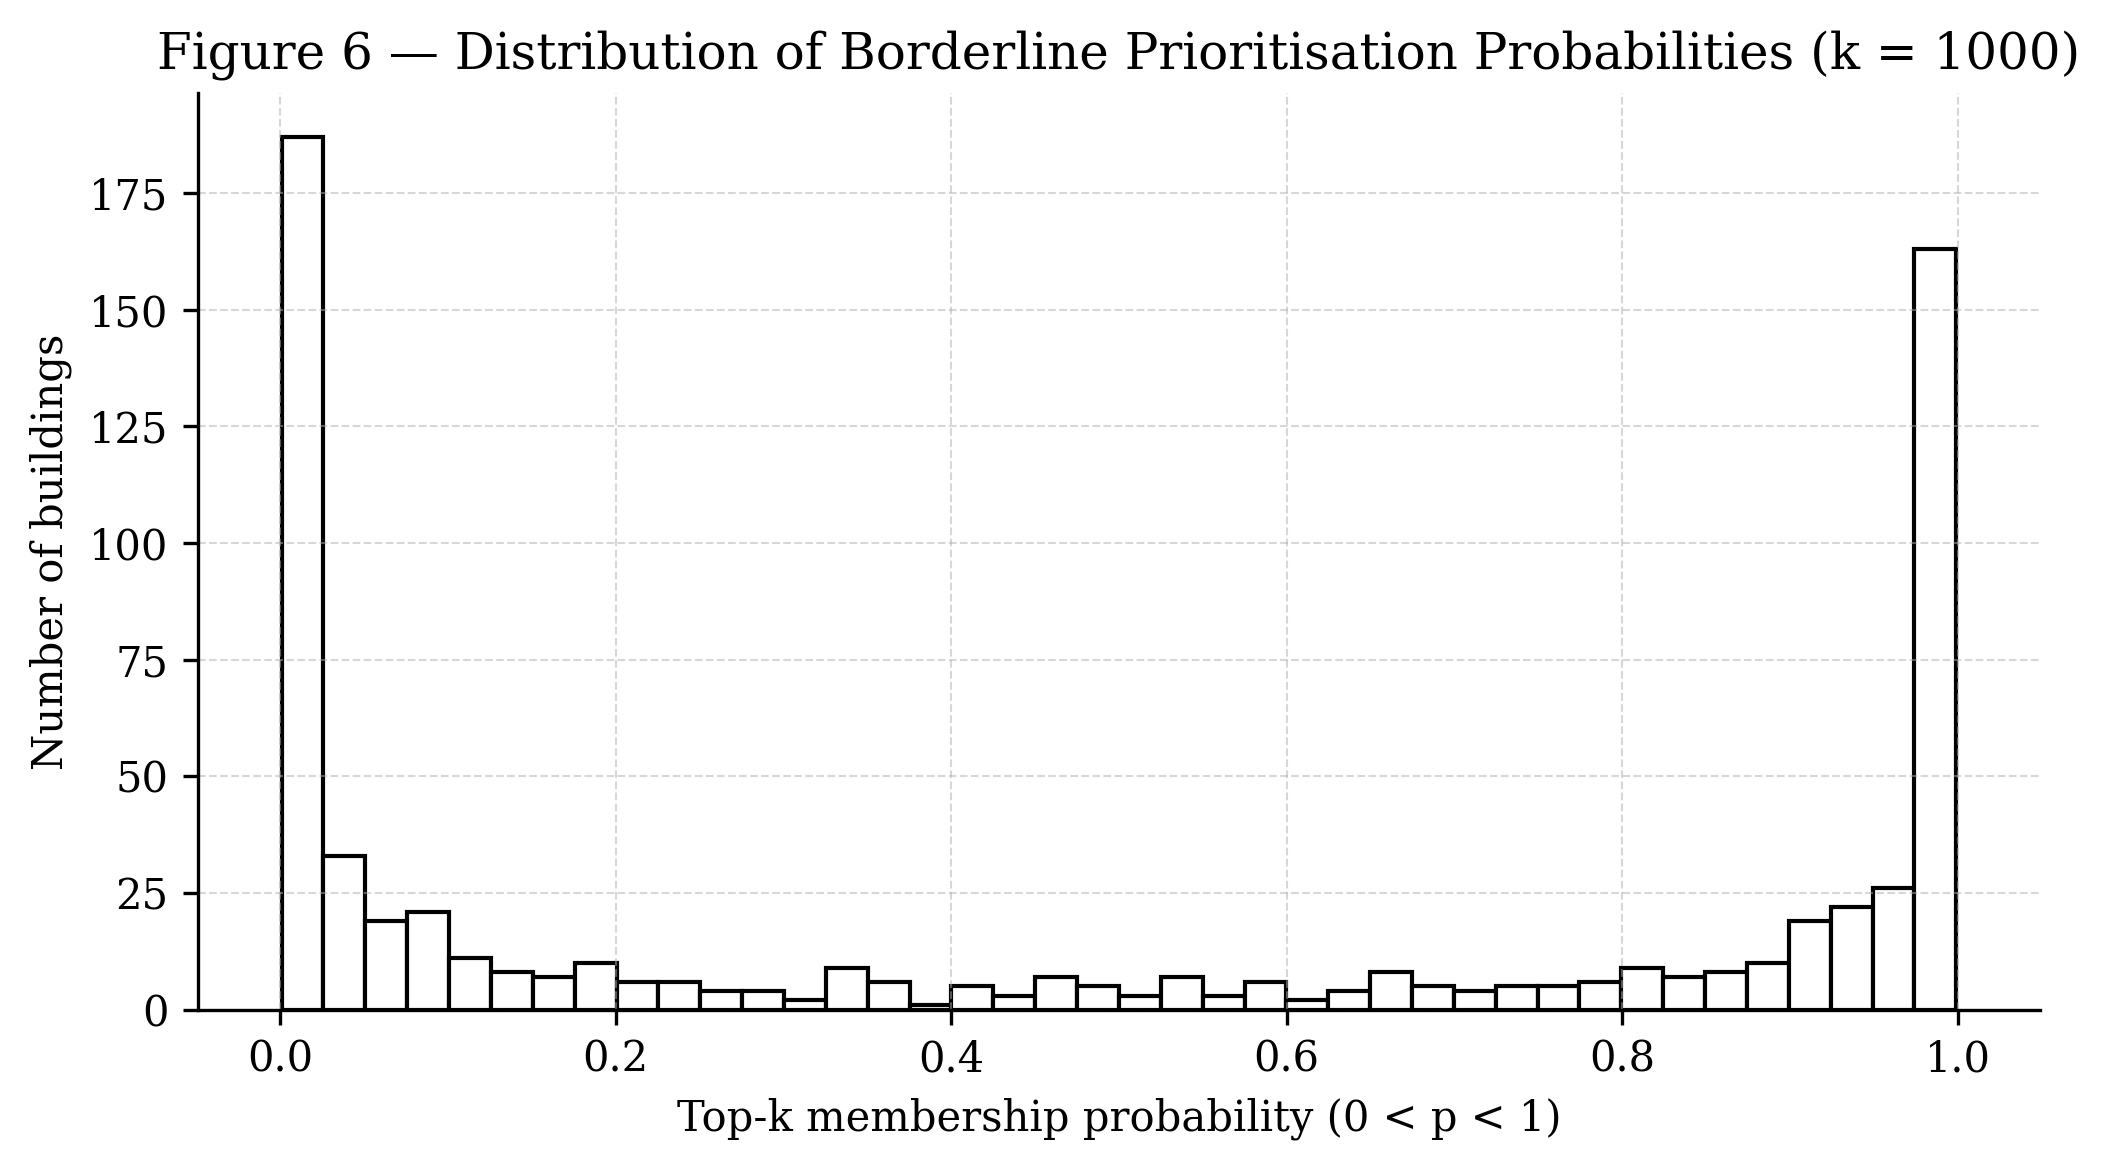

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- Journal friendly settings ---
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "serif"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

col = "topk_prob_city_1000"

vals = df_sc[col].values
unstable = vals[(vals > 0) & (vals < 1)]

print("Summary:")
print("Mean:", vals.mean())
print("Min:", vals.min())
print("Max:", vals.max())
print("Borderline share (0.2 < p < 0.8):",
      np.mean((vals > 0.2) & (vals < 0.8)))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7,4))

ax.hist(
    unstable,
    bins=40,
    color="white",
    edgecolor="black",
    linewidth=1
)

ax.set_xlabel("Top-k membership probability (0 < p < 1)")
ax.set_ylabel("Number of buildings")

ax.set_title("Figure 6 — Distribution of Borderline Prioritisation Probabilities (k = 1000)")

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# cleaner academic look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# --- Save vector versions ---
fig.savefig("fig06_topk_prob_histogram.pdf", bbox_inches="tight")
fig.savefig("fig06_topk_prob_histogram.svg", bbox_inches="tight")

plt.show()